In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Updated_sales.csv
/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data/Sales_August_2019.csv
/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data/Sales_May_2019.csv
/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data/Sales_February_2019.csv
/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data/Sales_November_2019.csv
/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data/Sales_January_2019.csv
/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data/Sales_March_2019.csv
/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data/Sales_September_2019.csv
/kaggle/input/datasets/deepanshuver

In [2]:
import pandas as pd
import os

files = []

for dirname, _, filenames in os.walk('/kaggle/input/datasets/deepanshuverma0154/sales-dataset-of-ecommerce-electronic-products/Sales_Data'):
    for filename in filenames:
        if filename.endswith('.csv'):
            files.append(os.path.join(dirname, filename))

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"


In [3]:
df.shape

(186850, 6)

In [4]:
df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [5]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

186850

In [6]:
pd.read_sql("SELECT COUNT(*) FROM sales", conn)

,COUNT(*)
0,186850


In [7]:
pd.read_sql("""
SELECT SUM("Quantity Ordered" * "Price Each") AS total_revenue
FROM sales
""", conn)

,total_revenue
0,3.449204e+07


In [8]:
pd.read_sql("""
SELECT Product, SUM("Quantity Ordered") as total_sold
FROM sales
GROUP BY Product
ORDER BY total_sold DESC
LIMIT 5
""", conn)

,Product,total_sold
0,AAA Batteries (4-pack),31017
1,AA Batteries (4-pack),27635
2,USB-C Charging Cable,23975
3,Lightning Charging Cable,23217
4,Wired Headphones,20557


In [9]:
pd.read_sql("""
SELECT SUBSTR("Order Date", 1, 2) AS month,
       SUM("Quantity Ordered" * "Price Each") as revenue
FROM sales
GROUP BY month
ORDER BY month
""", conn)

,month,revenue
0,None,NaN
1,01,1.822257e+06
2,02,2.202022e+06
3,03,2.807100e+06
4,04,3.390670e+06
5,05,3.152607e+06
6,06,2.577802e+06
7,07,2.647776e+06
8,08,2.244468e+06
9,09,2.097560e+06


In [10]:
pd.read_sql("""
SELECT SUBSTR("Purchase Address", INSTR("Purchase Address", ',')+2, 
       INSTR("Purchase Address", '(') - INSTR("Purchase Address", ',')-3) AS city,
       SUM("Quantity Ordered" * "Price Each") as revenue
FROM sales
GROUP BY city
ORDER BY revenue DESC
""", conn)

,city,revenue
0,"844 12th St,",6513.93
1,"874 4th St,",6506.87
2,"480 Hill St,",6289.75
3,"986 7th St,",5975.82
4,"354 Main St,",5829.89
...,...,...
46834,"111 Forest St,",2.99
46835,"111 8th St,",2.99
46836,"108 Elm St,",2.99
46837,P,0.00


In [11]:
pd.read_sql("""
SELECT SUBSTR("Order Date", 12, 2) as hour,
       COUNT(*) as total_orders
FROM sales
GROUP BY hour
ORDER BY total_orders DESC
""", conn)

,hour,total_orders
0,:1,31119
1,:0,31012
2,:2,31000
3,:3,30989
4,:5,30986
5,:4,30844
6,None,545
7,,355


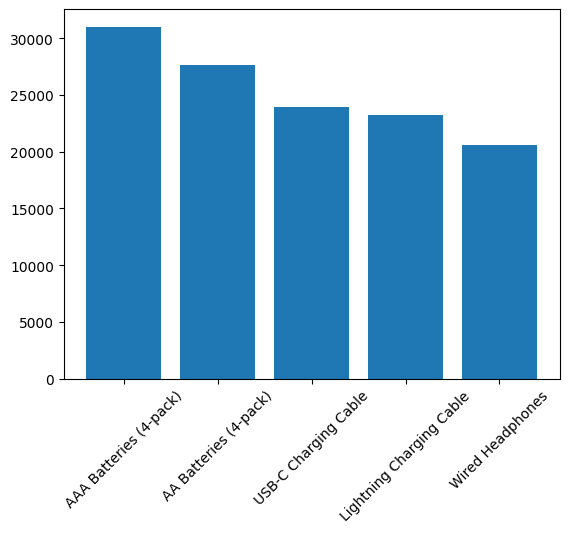

In [12]:
import matplotlib.pyplot as plt

data = pd.read_sql("""
SELECT Product, SUM("Quantity Ordered") as total_sold
FROM sales
GROUP BY Product
ORDER BY total_sold DESC
LIMIT 5
""", conn)

plt.bar(data['Product'], data['total_sold'])
plt.xticks(rotation=45)
plt.show()

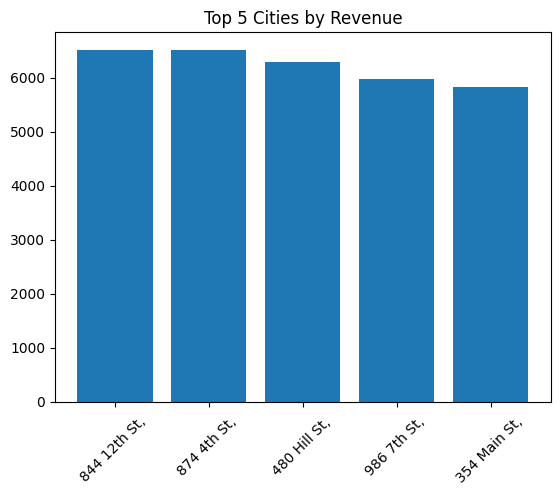

In [13]:
data = pd.read_sql("""
SELECT SUBSTR("Purchase Address", INSTR("Purchase Address", ',')+2, 
       INSTR("Purchase Address", '(') - INSTR("Purchase Address", ',')-3) AS city,
       SUM("Quantity Ordered" * "Price Each") as revenue
FROM sales
GROUP BY city
ORDER BY revenue DESC
LIMIT 5
""", conn)

plt.bar(data['city'], data['revenue'])
plt.xticks(rotation=45)
plt.title("Top 5 Cities by Revenue")
plt.show()